In [1]:
import h5py 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [27]:
folder = r"../data"
subjects = ["DB"]
df_all = []
for subject in subjects:
    folder_subject = os.path.join(folder, subject)
    filenames = os.listdir(folder_subject)
    # filenames = ["01_bar_feedback.csv", "02_bar_errorfeedback.csv", "03_vbar_feedback.csv", "04_vbar_errorfeedback_120fps.csv"]
    filenames = ["01_circle_feedback.csv", "03_bar_feedback.csv", "04_bar_feedback.csv", "05_bar_errorfeedback.csv"]
    for fl in filenames:
        if fl.find(".csv") == -1:
            continue
        if fl.find("120fps") != -1:
            continue
        df = pd.read_csv(os.path.join(folder_subject, fl))
        df["feedback"] = "circle"
        if fl.find("vbar") != -1:
            df["feedback"] = "vbar"
        elif fl.find("bar") != -1:
            df["feedback"] = "bar"
        #df["feedback"] = "bar" if fl.find("vbar") == -1 else "vbar"
        df["subject"] = subject
        df_all.append(df)
df = pd.concat(df_all, ignore_index=True)
df_all = []
for feedback in ["vbar", "bar", "circle"]:
    df_s = df.loc[df.feedback == feedback]
    df_s["n"] = np.arange(df_s.shape[0])
    print(df_s.shape)
    df_all.append(df_s)
df = pd.concat(df_all, ignore_index=True)

(0, 11)
(138, 11)
(50, 11)


In [28]:
df_bar = df.loc[df.feedback == "bar"]
df_circle = df.loc[df.feedback == "circle"]
df_vbar = df.loc[df.feedback == "vbar"]

In [29]:
df_circle.shape, df_bar.shape, df_vbar.shape

((50, 11), (138, 11), (0, 11))

In [30]:
def calculate_mean(df, n=10):
    df_mean = []
    for i in range(0, df.shape[0], n):
        val = df.loc[(df.n >i) & (df.n<(i+n))]["error"].mean()
        df_mean.append({"t": i+n//2, "error": round(val, 2)})
    return pd.DataFrame(df_mean)

In [31]:
def plot_error(df, n_mean=10, limits=None, title=None, ylim=None, yticks=None, xticks_step=None, figsize=None):
    df_mean = calculate_mean(df, n=n_mean)

    figsize = figsize if figsize is not None else (6, 6)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=12)

    ax.axhline(0, linewidth=5, color="#9649ED")

    sns.lineplot(df, x="n", y="error", ax=ax, linewidth=1, color="#280E7E", label="Error per trial")
    sns.lineplot(df_mean, x="t", y="error", linewidth=3, color="#C90CA7", label=f"Binned mean error (n = {n_mean})")

    # err_feedback = df.loc[df.feedback == "error_feedback"]["n"].values[0]
    # ax.axvline(err_feedback, linewidth=3, color="#167E51")
    # ax.text(x=err_feedback+2, y=ylim[1]-20, s="error feedback")

    if xticks_step is not None:
        ax.set_xticks(np.arange(0, df.shape[0], xticks_step))
    if yticks is not None:
        ax.set_yticks(yticks)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(linewidth=.5, color='lightgrey')
    if title is not None:
        ax.set_title(title, fontsize=16, y=1.02)
    if limits is not None:
        xmin, xmax = plt.xlim()
        ax.fill_between([xmin, xmax], y1=limits[0], y2=limits[1], alpha=.3, color="#28076F", label=f"Acceptable range {limits} ms")
        ax.set_xlim(xmin, xmax)
    
    ax.set_xlabel("№ попытки", fontsize=14)
    ax.set_ylabel("ошибка [мс]", fontsize=14, labelpad=-.01)

    ax.legend(loc=[0.01, 0.01])

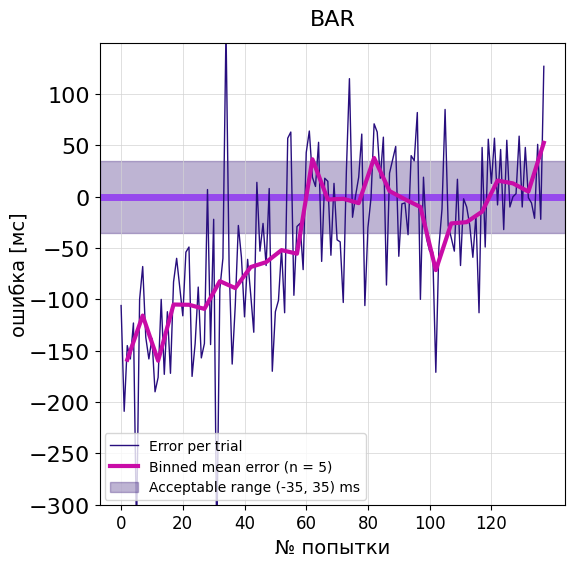

In [32]:
plot_error(df_bar, n_mean=5, limits=(-35, 35), title="BAR", ylim=(-300, 150), yticks=np.arange(-300, 150, 50), xticks_step=20) #ylim=(-150, 75), yticks=np.arange(-200, 100, 25), x

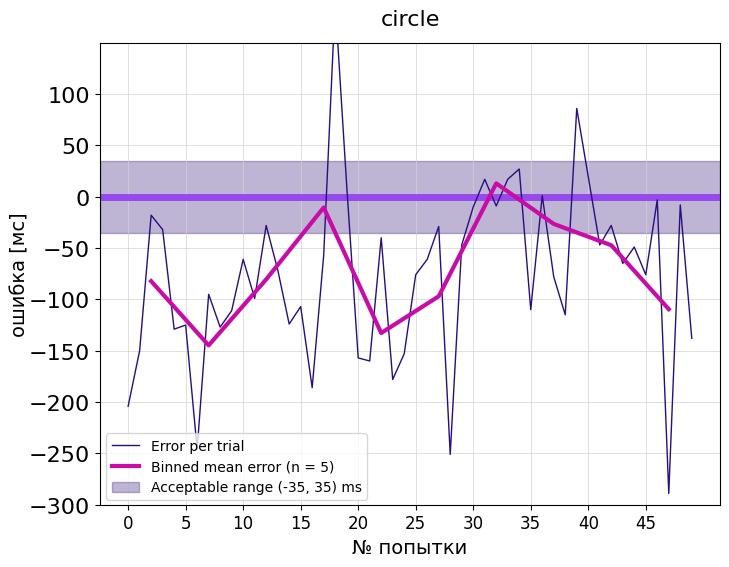

In [9]:
plot_error(df_circle, n_mean=5, limits=(-35, 35), title="circle", ylim=(-300, 150), yticks=np.arange(-300, 150, 50), xticks_step=5, figsize=(8, 6)) #ylim=(-150, 100), yticks=np.arange(-200, 200, 25),

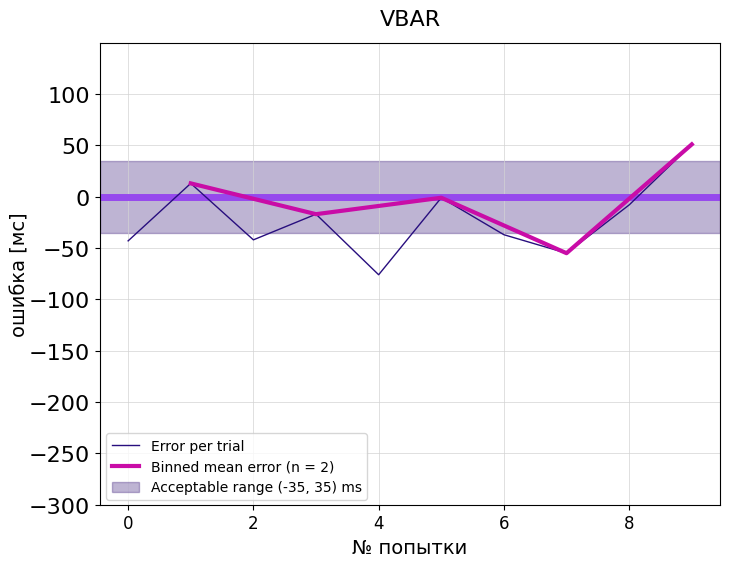

In [32]:
plot_error(df_vbar, n_mean=2, limits=(-35, 35), title="VBAR", ylim=(-300, 150), yticks=np.arange(-300, 150, 50), xticks_step=2, figsize=(8, 6))

In [ ]:
df_check = df_tim.copy()
err_feedback = df_check.loc[df_check.feedback == "error_feedback"]["n"].values[0]

df_check[err_feedback-30:err_feedback]["error"].mean(), df_check[err_feedback-30:err_feedback]["error"].std()

(np.float64(-31.966666666666665), np.float64(50.95805126283526))

In [ ]:
err_feedback = df_alsu.loc[df_alsu.feedback == "error_feedback"]["n"].values[0]

df_alsu[err_feedback-30:err_feedback]["error"].std()

In [ ]:
def plot_error_plot(filename=None, df=None, ax=None, title=None):
    if filename is not None:
        df = pd.read_csv(filename)
    if df is None:
        return
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    legend_status = True if len(df["ponk_number"].unique()) > 1 else False
    sns.lineplot(df, x="stimulus_number", y="error", hue="ponk_number",marker="*", color='purple', ax=ax, legend=legend_status)
    ax.set_xticks(df["stimulus_number"].unique()[::5])
    ax.set_ylim(-400, 400)
    ax.set_ylabel("error [ms]")
    if title is not None:
        ax.set_title(title)
    ax.axhline(0, ls="--", linewidth=.5, color="black")
    return ax

<Axes: title={'center': 'SINGLE -- FEEDBACK'}, xlabel='stimulus_number', ylabel='error [ms]'>

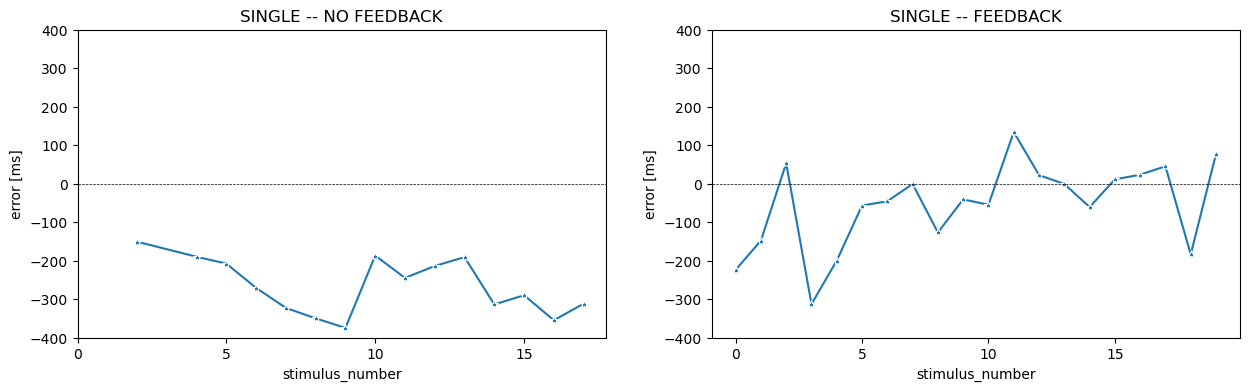

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
filename = os.path.join(folder, "01IB_01_single_NoFB.csv")
plot_error_plot(filename, ax[0], title="SINGLE -- NO FEEDBACK")
filename = os.path.join(folder, "01IB_02_single_FB.csv")
plot_error_plot(filename, ax[1], title="SINGLE -- FEEDBACK")

<Axes: title={'center': 'TRIPLETS -- FEEDBACK'}, xlabel='stimulus_number', ylabel='error [ms]'>

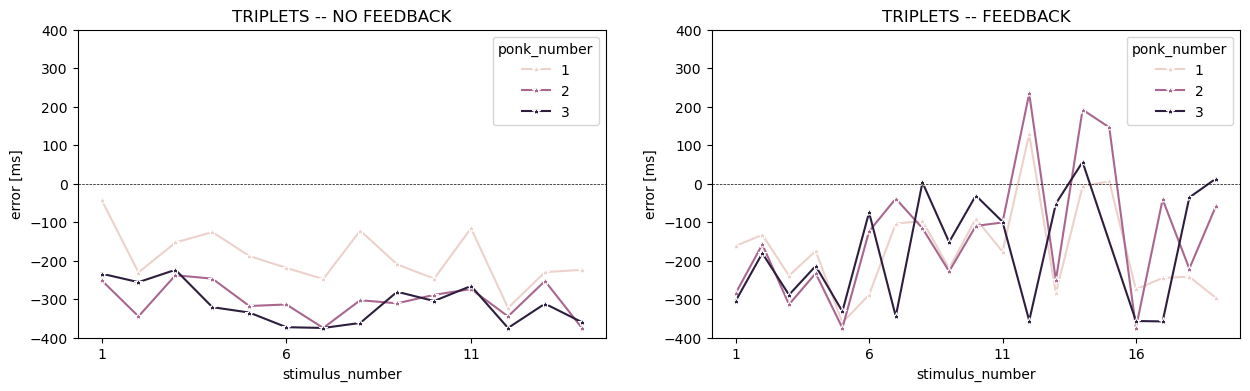

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
filename = os.path.join(folder, "01IB_03_triplets_NoFB.csv")
plot_error_plot(filename, ax[0], title="TRIPLETS -- NO FEEDBACK")
filename = os.path.join(folder, "01IB_04_triplets_FB-01.csv")
plot_error_plot(filename, ax[1], title="TRIPLETS -- FEEDBACK")

In [129]:
df_fb = []
n = 1
for filename in ['01IB_04_triplets_FB-01.csv', '01IB_05_triplets_FB-02.csv', '01IB_06_triplets_FB-03.csv', '01IB_07_triplets_FB-04.csv']:
    df = pd.read_csv(os.path.join(folder, filename))
    df["session_n"] = n
    n += 1
    df_fb.append(df)
df_fb = pd.concat(df_fb, ignore_index=True)
df_fb["stimulus_number"] = np.repeat(range(1, int(df_fb.shape[0]//3)+1), 3)

In [135]:
df_fb["session_n"].value_counts()

session_n
4    189
3    120
2     90
1     57
Name: count, dtype: int64

In [143]:
df = df_fb.copy()

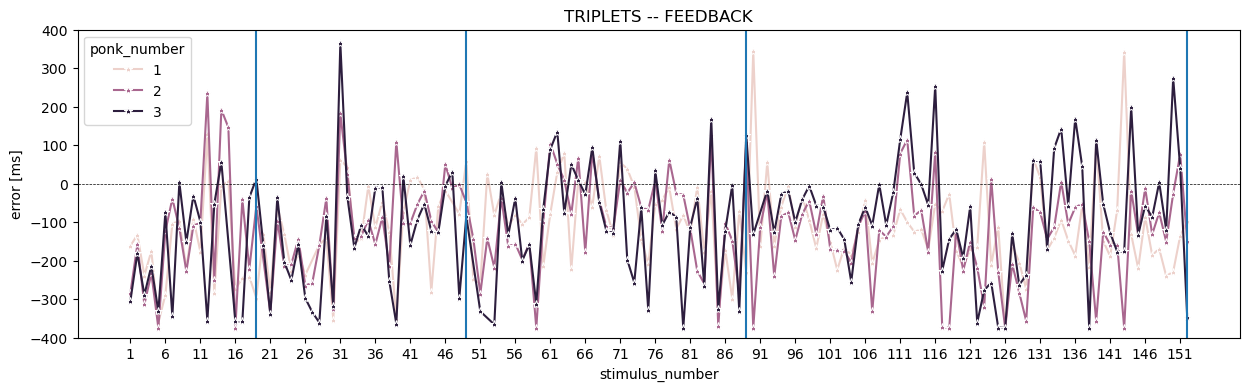

In [144]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plot_error_plot(df=df, title="TRIPLETS -- FEEDBACK", ax=ax)
for n in np.cumsum([57, 90, 120, 189])//3:
    ax.axvline(n)

<Axes: xlabel='error', ylabel='Count'>

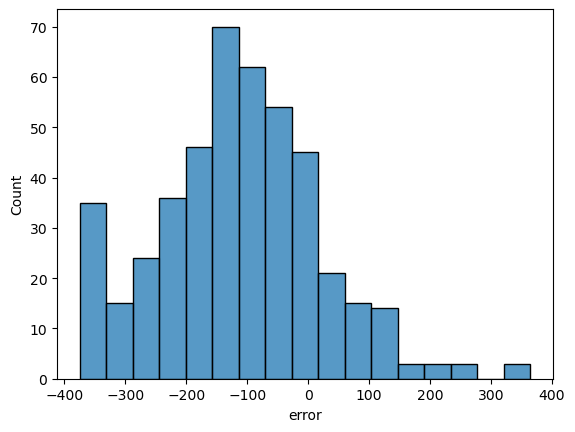

In [159]:
sns.histplot(df, x="error")

(-400.0, 400.0)

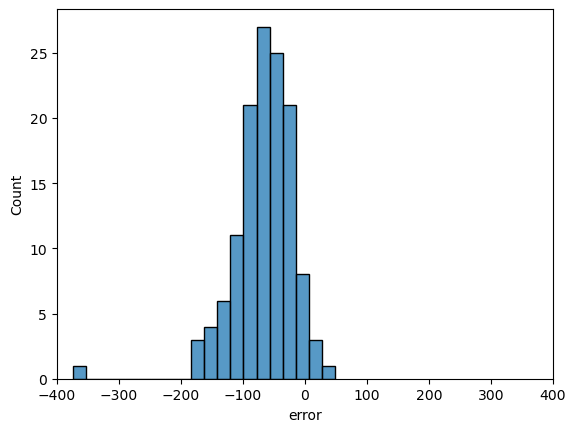

In [160]:
filename = os.path.join(r"../data/tests/02AV_eFB.csv")
df_a = pd.read_csv(filename)
sns.histplot(df_a, x="error")
plt.xlim(-400, 400)

<Axes: xlabel='session_n', ylabel='error'>

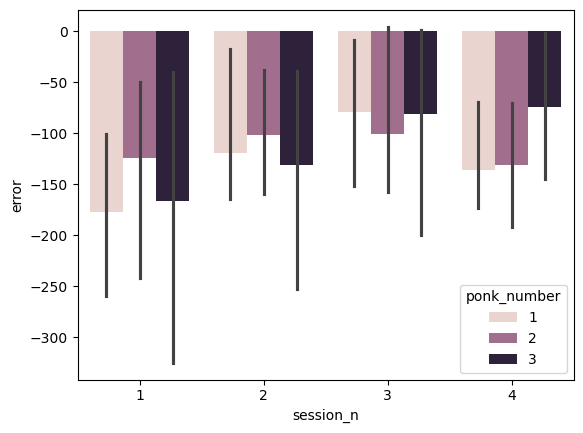

In [149]:
sns.barplot(df, x="session_n", y="error", hue="ponk_number", estimator="median", errorbar=("pi", 50))